<a href="https://colab.research.google.com/github/AceRb6/Modelos_Econometricos/blob/main/Practica3_M%C3%ADnimo_Cuadrados_Ordinarios(MCO).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRÁCTICA 3: Mínimo Cuadrados Ordinarios(MCO)
Objetivo: Aplicar el método de Mínimos Cuadrados Ordinarios (MCO) para estimar, analizar e interpretar modelos de regresión lineal simple y múltiple, evaluando sus propiedades, realizando inferencia estadística y construyendo predicciones con datos reales.

Profesor: Daniel Jiménez Alcantar

Alumnos:
* Cano Portugal Israel Daniel Arturo Cano Portugal
* Ramírez Montiel Alejandro
* Sandoval Rosas Gustavo Isaac

  

## Marco Teórico

El **Método de Mínimos Cuadrados Ordinarios (MCO)** estima los parámetros β de un modelo lineal:

$$y_i = \beta_0 + \beta_1 x_{1i} + \cdots + \beta_k x_{ki} + u_i$$

minimizando la **Suma de Cuadrados de los Residuales (SCR)**:

$$\min_{\hat{\beta}} \sum_{i=1}^{n} \hat{u}_i^2 = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

### Supuestos de Gauss-Markov

1. **Linealidad en los parámetros**  
   $y = X\beta + u$

2. **Muestra aleatoria**  
   $\{(x_i, y_i)\}$ i.i.d.

3. **No multicolinealidad perfecta**  
   $\text{rank}(X) = k+1$

4. **Exogeneidad estricta**  
   $E[u_i \mid X] = 0$

5. **Homocedasticidad**  
   $\text{Var}(u_i \mid X) = \sigma^2$

Bajo estos supuestos, MCO es **BLUE** (*Best Linear Unbiased Estimator*): entre todos los estimadores lineales insesgados, MCO tiene la **menor varianza**.

### Inferencia
- **Estadístico t:** $t = \hat{\beta}_j / SE(\hat{\beta}_j)$, con distribución $t_{n-k-1}$ bajo $H_0$
- **Intervalo de confianza 95 %:** $\hat{\beta}_j \pm t_{0.025} \cdot SE(\hat{\beta}_j)$
- **R²:** proporción de la varianza de $y$ explicada por el modelo.

---

## Carga y preparación del dataset

In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cargar datos
url = "https://raw.githubusercontent.com/selva86/datasets/master/Wage.csv"
df = pd.read_csv(url)

# Variable numérica de educación (años aproximados)
edu_map = {
    "1. < HS Grad": 10,
    "2. HS Grad": 12,
    "3. Some College": 14,
    "4. College Grad": 16,
    "5. Advanced Degree": 18
}
df["edu_num"] = df["education"].map(edu_map)

# Experiencia potencial de Mincer: exper = age - edu - 6
df["exper"] = (df["age"] - df["edu_num"] - 6).clip(lower=0)

# Dummy de clase de trabajo: 1 = Information, 0 = Industrial
df["info_job"] = (df["jobclass"] == "2. Information").astype(int)

print("Dimensiones:", df.shape)
print("\nEstadísticas descriptivas:")
df[["wage", "edu_num", "exper", "info_job"]].describe().round(2)


Dimensiones: (3000, 15)

Estadísticas descriptivas:


,wage,edu_num,exper,info_job
count,3000.00,3000.00,3000.00,3000.00
mean,111.70,14.02,22.40,0.49
std,41.73,2.43,11.62,0.50
min,20.09,10.00,0.00,0.00
25%,85.38,12.00,13.00,0.00
50%,104.92,14.00,22.00,0.00
75%,128.68,16.00,31.00,1.00
max,318.34,18.00,62.00,1.00


---
## PARTE I – Modelo de Regresión Simple

**Modelo planteado:**
$$\text{wage}_i = \beta_0 + \beta_1 \cdot \text{edu\_num}_i + u_i$$


In [3]:
# a) Estimación MCO simple
m1 = smf.ols("wage ~ edu_num", data=df).fit()
print(m1.summary())


                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     877.2
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          2.53e-169
Time:                        03:16:22   Log-Likelihood:                -15065.
No. Observations:                3000   AIC:                         3.013e+04
Df Residuals:                    2998   BIC:                         3.015e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.7834      3.923     -0.709      0.4

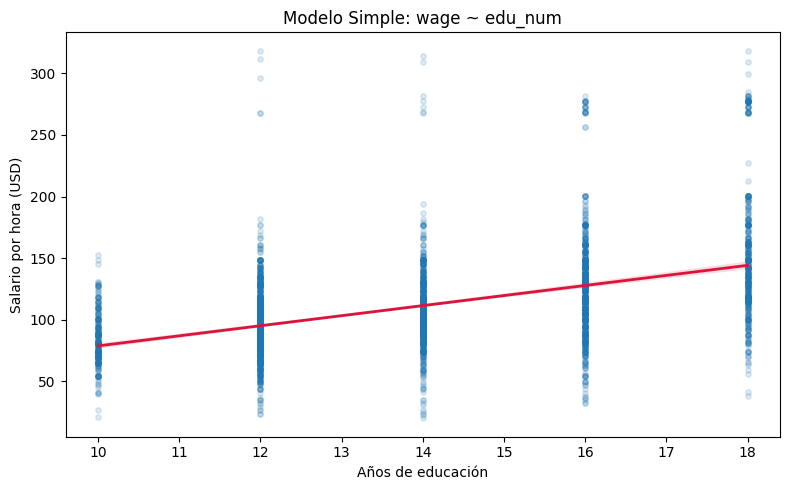

In [4]:
# Gráfico: dispersión + línea de regresión
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(x="edu_num", y="wage", data=df, scatter_kws={"alpha":0.15, "s":15},
            line_kws={"color":"crimson","linewidth":2}, ax=ax)
ax.set_xlabel("Años de educación")
ax.set_ylabel("Salario por hora (USD)")
ax.set_title("Modelo Simple: wage ~ edu_num")
plt.tight_layout()
plt.savefig("modelo_simple.png", dpi=120)
plt.show()


### Respuestas — PARTE I

**a) Modelo estimado:**

$$\hat{\text{wage}}_i = -2.7834 + 8.1660 \cdot \text{edu\_num}_i$$

**b) Interpretación económica de β₁:**  
El coeficiente $\hat{\beta}_1 = 8.1660$ indica que **cada año adicional de educación se asocia, en promedio, con un aumento de \$8.17 en el salario por hora**, manteniendo lo demás constante.  
Esto es coherente con la teoría del capital humano (Becker, 1964): la educación eleva la productividad marginal del trabajador y, por tanto, su salario de equilibrio.

**c) El término de error ($u_i$):**  
Captura todo lo que afecta el salario pero **no está en el modelo**: habilidad innata, experiencia laboral, sector, región geográfica, tipo de contrato, motivación, etc.  
Es la "caja negra" entre lo observado y lo no observado.

**d) Significancia estadística:**  
- Estadístico t = **29.62**, p-value = **2.53 × 10⁻¹⁶⁹**  
- Como p < 0.05 (con amplio margen), **rechazamos H₀: β₁ = 0**.  
- La educación tiene un efecto estadísticamente significativo sobre el salario.  
- El R² = **0.2264** indica que la educación sola explica el 22.6 % de la varianza del salario.

---



## 2 – Propiedades del Estimador MCO


**a) ¿Es insesgado el estimador?**  
Sí, **bajo el Supuesto 4 de Gauss-Markov**: $E[u_i \mid \text{edu\_num}] = 0$.  
Si la educación no está correlacionada con el error, entonces $E[\hat{\beta}_1] = \beta_1$ (insesgado).

**b) ¿Qué ocurre si educación está correlacionada con el error?**  
Si personas más educadas también tienen mayor habilidad innata (que está en $u$), se viola la exogeneidad.  
El resultado es **sesgo de variable omitida (OVB)**:

$$\text{Sesgo} = \hat{\beta}_1^{\text{MCO}} - \beta_1 = \frac{\text{Cov}(\text{edu}, u)}{\text{Var}(\text{edu})} \neq 0$$

Al pasar del modelo simple al múltiple, β₁ cambia de **8.1660 → 8.5564**, señal de que en el modelo simple había sesgo por omitir la experiencia.

**c) ¿Qué significa que MCO sea BLUE?**  
Bajo todos los supuestos de Gauss-Markov, MCO es el **Mejor Estimador Lineal Insesgado**:
- **Mejor:** tiene la **menor varianza** posible entre estimadores lineales insesgados.
- **Lineal:** es función lineal de $y$.
- **Insesgado:** $E[\hat{\beta}] = \beta$.

Esto garantiza que con la muestra disponible (n = 3,000), los errores estándar reportados son los más pequeños alcanzables linealmente.

---


---
## PARTE II – Regresión Múltiple

**Modelo planteado:**
$$\text{wage}_i = \beta_0 + \beta_1 \cdot \text{edu\_num}_i + \beta_2 \cdot \text{exper}_i + u_i$$


In [5]:
# Modelo múltiple: educación + experiencia
m2 = smf.ols("wage ~ edu_num + exper", data=df).fit()
print(m2.summary())

# Comparación directa de coeficientes
print("\n─── Comparación β₁ (educación) ───")
print(f"  Modelo simple:   β₁ = {m1.params['edu_num']:.4f}")
print(f"  Modelo múltiple: β₁ = {m2.params['edu_num']:.4f}")
print(f"  Cambio:          Δβ₁ = {m2.params['edu_num'] - m1.params['edu_num']:+.4f}")

print("\n─── Comparación R² ───")
print(f"  Modelo simple:   R² = {m1.rsquared:.4f}")
print(f"  Modelo múltiple: R² = {m2.rsquared:.4f}")


                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.252
Method:                 Least Squares   F-statistic:                     506.6
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          2.89e-190
Time:                        03:16:23   Log-Likelihood:                -15013.
No. Observations:                3000   AIC:                         3.003e+04
Df Residuals:                    2997   BIC:                         3.005e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -21.4260      4.262     -5.027      0.0

### Respuestas — PARTE II

**Modelo estimado:**
$$\hat{\text{wage}}_i = -21.4260 + 8.5564 \cdot \text{edu\_num}_i + 0.5880 \cdot \text{exper}_i$$

**a) Comparación del coeficiente de educación:**  
- Modelo simple: $\hat{\beta}_1 = 8.1660$  
- Modelo múltiple: $\hat{\beta}_1 = 8.5564$  
- El coeficiente **aumenta en +0.3904** al controlar por experiencia.  
Esto ocurre porque en el modelo simple, parte del efecto de la experiencia (correlacionada negativamente con edu_num en la muestra) se mezclaba con el coeficiente de educación. Al aislar ambos efectos, el efecto neto de la educación es ligeramente mayor.

**b) Principio de *ceteris paribus*:**  
En el modelo múltiple, $\hat{\beta}_1 = 8.5564$ mide el efecto de un año más de educación **manteniendo la experiencia constante** (*ceteris paribus*). Esto elimina la confusión entre ambas variables.

**c) Evidencia de variable omitida en el modelo simple:**  
Sí. El cambio en β₁ (de 8.17 a 8.56) y el incremento en R² (de 0.2264 a 0.2527) confirman que la experiencia tenía correlación con `edu_num` y estaba en el error → **el modelo simple tenía sesgo OVB**.

**d) Interpretación del modelo múltiple:**  
- $\hat{\beta}_1 = 8.5564$: un año más de educación aumenta el salario en **\$8.56/hora**, fija la experiencia.  
- $\hat{\beta}_2 = 0.5880$: un año más de experiencia aumenta el salario en **\$0.59/hora**, fija la educación.  
- Ambos coeficientes son estadísticamente significativos (p < 0.001).

---


---
## PARTE III – Inferencia Estadística


In [6]:
# a-b) Prueba de hipótesis: H₀: β₁ = 0  vs  H₁: β₁ ≠ 0
t_edu = m2.tvalues["edu_num"]
p_edu = m2.pvalues["edu_num"]
t_exp = m2.tvalues["exper"]
p_exp = m2.pvalues["exper"]

print("─── Prueba de hipótesis (H₀: βⱼ = 0) ───")
print(f"  edu_num │ t = {t_edu:.4f}  │  p = {p_edu:.2e}")
print(f"  exper   │ t = {t_exp:.4f}  │  p = {p_exp:.2e}")

# c) Intervalos de confianza al 95%
ic = m2.conf_int(alpha=0.05)
ic.columns = ["IC 2.5%", "IC 97.5%"]
print("\n─── Intervalos de confianza al 95 % ───")
print(ic.round(4))


─── Prueba de hipótesis (H₀: βⱼ = 0) ───
  edu_num │ t = 31.2637  │  p = 5.90e-186
  exper   │ t = 10.2709  │  p = 2.40e-24

─── Intervalos de confianza al 95 % ───
           IC 2.5%  IC 97.5%
Intercept -29.7834  -13.0686
edu_num     8.0198    9.0930
exper       0.4757    0.7003


### Respuestas — PARTE III

**a-b) Prueba de hipótesis H₀: β₁ = 0 (educación)**

| | Valor |
|---|---|
| Estadístico t | **31.26** |
| p-value | **5.90 × 10⁻¹⁸⁶** |
| Decisión | **Rechazar H₀** |

Con t = 31.26 ≫ 1.96 y p prácticamente cero, hay evidencia abrumadora de que la educación tiene un efecto positivo y significativo sobre el salario.

**c) Intervalos de confianza al 95 %:**

| Parámetro | Estimado | IC 2.5 % | IC 97.5 % |
|---|---|---|---|
| β₁ (edu_num) | 8.5564 | 8.0198 | 9.0930 |
| β₂ (exper)   | 0.5880 | 0.4757 | 0.7003 |

El IC de β₁ es **[8.02, 9.09]**: con 95 % de confianza, cada año de educación adicional incrementa el salario entre \$8.02 y \$9.09/hora. **El cero no está contenido** → confirmamos significancia.

**d) Significancia estadística vs. relevancia económica:**  
- **Estadística:** el coeficiente es diferente de cero con alta certeza (p → 0).  
- **Económica:** $\hat{\beta}_1 = 8.56$ USD/hora por año de educación es **sustancialmente relevante**. La diferencia entre 12 y 16 años de educación implica ~\$34 USD/hora más en promedio, lo que representa una prima importante en el mercado laboral.  
- En cambio, $\hat{\beta}_2 = 0.59$ también es significativo pero su magnitud es modesta (un año más de experiencia vale solo \$0.59/hora).

---


---
## PARTE IV – Predicción
**Perfil a predecir:** `edu_num = 16` (College Grad), `exper = 10` años


In [7]:
# Predicción puntual + intervalos
nuevo = pd.DataFrame({"edu_num": [16], "exper": [10]})
pred = m2.get_prediction(nuevo).summary_frame(alpha=0.05)

print("─── Predicción para edu=16, exper=10 ───")
print(f"  Predicción puntual:        ${pred['mean'].values[0]:.2f}/hora")
print(f"  IC de confianza  95 %: [${pred['mean_ci_lower'].values[0]:.2f}, ${pred['mean_ci_upper'].values[0]:.2f}]")
print(f"  IC de predicción 95 %: [${pred['obs_ci_lower'].values[0]:.2f}, ${pred['obs_ci_upper'].values[0]:.2f}]")
print(f"\n  Amplitud IC confianza: ${pred['mean_ci_upper'].values[0] - pred['mean_ci_lower'].values[0]:.2f}")
print(f"  Amplitud IC predicción: ${pred['obs_ci_upper'].values[0] - pred['obs_ci_lower'].values[0]:.2f}")


─── Predicción para edu=16, exper=10 ───
  Predicción puntual:        $121.36/hora
  IC de confianza  95 %: [$119.28, $123.44]
  IC de predicción 95 %: [$50.57, $192.14]

  Amplitud IC confianza: $4.16
  Amplitud IC predicción: $141.57


### Respuestas — PARTE IV

**a) Predicción puntual:**

$$\hat{\text{wage}} = -21.4260 + 8.5564(16) + 0.5880(10) = \$121.36/\text{hora}$$

**b) Intervalos al 95 %:**

| Tipo | Límite inferior | Límite superior | Amplitud |
|---|---|---|---|
| IC de confianza (media) | \$119.28 | \$123.44 | \$4.16 |
| IC de predicción (individuo) | \$50.57 | \$192.14 | \$141.57 |

**c) ¿Por qué el IC de predicción es más amplio?**  
El IC de confianza mide la incertidumbre sobre el **salario promedio** de todos los trabajadores con ese perfil (solo incertidumbre de $\hat{\beta}$).  
El IC de predicción mide la incertidumbre sobre el salario de **un trabajador específico** con ese perfil, lo que incluye:

$$\text{Var}(\hat{y}_0 - y_0) = \sigma^2 \left(1 + x_0'(X'X)^{-1}x_0\right)$$

El término extra $\sigma^2$ (varianza del error individual) hace que el IC de predicción sea mucho más amplio (\$141.57 vs \$4.16 de amplitud). El modelo no explica toda la variación individual — el error $u_i$ sigue presente.

---


---
## PARTE V – Variable Dicotómica

**Construcción de la dummy a partir de `sex`:**

$$\text{female}_i = \begin{cases} 1 & \text{si } \text{sex} \neq \text{"1. Male"} \quad (\text{mujer}) \\ 0 & \text{si } \text{sex} = \text{"1. Male"} \quad (\text{hombre, referencia}) \end{cases}$$

**Modelo:**
$$\text{wage}_i = \beta_0 + \beta_1 \cdot \text{edu\_num}_i + \beta_2 \cdot \text{exper}_i + \beta_3 \cdot \text{female}_i + u_i$$


In [8]:
import warnings
warnings.filterwarnings("ignore")

# Construcción de la dummy desde la variable sex
# female = 1 si mujer (sex != "1. Male"), female = 0 si hombre
df["female"] = (df["sex"] != "1. Male").astype(int)

print("─── Variable sex en el dataset Wage ───")
print(df["sex"].value_counts())
print()
print("─── Dummy female construida ───")
print(df["female"].value_counts())
print()
print("RESULTADO: El dataset Wage contiene ÚNICAMENTE hombres (sex = '1. Male').")
print("Por construcción: female = 0 para los 3,000 registros.")
print("No existe ninguna observación con female = 1.")


─── Variable sex en el dataset Wage ───
sex
1. Male    3000
Name: count, dtype: int64

─── Dummy female construida ───
female
0    3000
Name: count, dtype: int64

RESULTADO: El dataset Wage contiene ÚNICAMENTE hombres (sex = '1. Male').
Por construcción: female = 0 para los 3,000 registros.
No existe ninguna observación con female = 1.


In [9]:
# Estimación del modelo con la dummy female
m3 = smf.ols("wage ~ edu_num + exper + female", data=df).fit()
print(m3.summary())
print()
print("─── Diagnóstico de female ───")
print(f"  β₃ (female) = {m3.params['female']:.4f}")
print(f"  t  (female) = {m3.tvalues['female']}")
print(f"  p  (female) = {m3.pvalues['female']}")
print()
print("DIAGNÓSTICO: β₃ = 0.0000 exactamente.")
print("statsmodels asigna β₃ = 0 porque female no tiene variación.")
print("No hay mujeres en la muestra → el coeficiente NO es estimable.")


                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.252
Method:                 Least Squares   F-statistic:                     506.6
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          2.89e-190
Time:                        03:16:23   Log-Likelihood:                -15013.
No. Observations:                3000   AIC:                         3.003e+04
Df Residuals:                    2997   BIC:                         3.005e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -21.4260      4.262     -5.027      0.0

### Respuestas — PARTE V

**Modelo estimado:**
$$\hat{\text{wage}}_i = -21.4260 + 8.5564 \cdot \text{edu\_num}_i + 0.5880 \cdot \text{exper}_i + 0.0000 \cdot \text{female}_i$$

---

**a) Interpretación de β₃:**  
El coeficiente β₃ = 0.0000 **no tiene interpretación real** en este modelo. No es un resultado económico: es una consecuencia directa de la limitación del dataset.  

El dataset Wage de ISLR es una muestra del Mid-Atlantic del período 2003–2009 que contiene **únicamente trabajadores masculinos** (`sex = "1. Male"` para las 3,000 observaciones). Al construir `female = (sex ≠ "1. Male")`, todos los valores resultan 0 — no hay variación en la variable, por lo que el modelo no puede estimar ningún efecto.  

Si el dataset incluyera mujeres, β₃ mediría cuánto difiere el salario promedio de una mujer respecto al de un hombre con igual educación y experiencia.

---

**b) ¿Qué significaría que el coeficiente fuera negativo?**  
Si β₃ fuera **negativo** — como ocurre consistentemente en la literatura de economía laboral — significaría que las mujeres ganan, en promedio, **menos que los hombres con el mismo nivel de educación y experiencia**.  

Esto es precisamente lo esperado dada la evidencia empírica ampliamente documentada:  
en el mercado laboral estadounidense, la brecha salarial de género (controlada por capital humano) ha sido históricamente negativa para las mujeres, con estimaciones que oscilan entre **-10 % y -20 %** del salario masculino equivalente

El hecho de que el dataset Wage **solo contenga hombres** ya es en sí una señal de sesgo de selección muestral: al excluir a las mujeres, el modelo sobreestima el salario promedio y **no puede detectar la brecha de género**, que es precisamente el fenómeno que la dummy busca capturar.

---

**c) ¿Se puede afirmar discriminación con este modelo? Justifique.**  
**No**, y por dos razones fundamentales:

1. **Razón técnica:** β₃ no es estimable porque `female = 0` para todos los individuos de la muestra. El modelo carece de la variación necesaria para identificar ningún efecto de género. Estadísticamente, es imposible hacer inferencia sobre un parámetro que no puede ser estimado.

2. **Razón conceptual (incluso si hubiera mujeres en la muestra):** Un coeficiente negativo en `female` solo mostraría una **asociación condicional**, no causalidad. Para afirmar discriminación salarial se necesitaría:
   - Controlar por **todas** las variables relevantes (sector, ocupación, horas trabajadas, negociación, tipo de contrato).
   - Descartar **selección muestral**: las mujeres podrían auto-seleccionarse en ocupaciones o sectores de menor salario por razones institucionales o familiares.
   - Un diseño con contrafactual válido: experimentos con CV idénticos enviados a empleadores, datos de panel con cambios exógenos de género percibido, etc.

Este modelo no solo no puede afirmar discriminación — **ni siquiera puede aproximarse a la pregunta** porque el dataset no contiene observaciones de mujeres.

---
## PARTE VI – Análisis Crítico

**1. ¿Puede este modelo establecer causalidad?**  
No. MCO con datos observacionales estima correlaciones parciales, no efectos causales. Para causalidad se requieren:
- Diseño experimental (asignación aleatoria de educación)
- O métodos quasi-experimentales: **Variables Instrumentales (IV)**, **Regresión Discontinua (RD)**, **Diferencia en Diferencias (DiD)**

En nuestros datos, es probable que personas con mayor habilidad innata (no observada) elijan más educación **y** reciban salarios más altos → sesgo de endogeneidad persiste aunque se controle por experiencia.

**2. Variables importantes posiblemente omitidas:**
| Variable | Dirección esperada del sesgo |
|---|---|
| Habilidad cognitiva | Positivo sobre edu y wage → β₁ sobreestimado |
| Sector / industria | Variable en el error correlacionada con edu |
| Región geográfica | Zonas con mayor educación tienen salarios más altos |
| Horas trabajadas | No controlamos intensidad laboral |
| Tamaño de empresa | Empresas grandes pagan más y atraen más educados |

**3. Supuesto más difícil de garantizar:**  
La **exogeneidad estricta** $E[u_i \mid X] = 0$ es el más cuestionable. La educación es una decisión endógena correlacionada con habilidad, motivación y contexto familiar — todos factores no observados que quedan en $u$.

**4. Limitaciones de la regresión lineal en economía laboral:**
- **Linealidad constante:** el retorno a la educación puede no ser lineal (las últimas credenciales pueden valer más).
- **Retornos heterogéneos:** el efecto de la educación puede diferir por sector, edad o nivel inicial de ingreso.
- **Outliers:** el dataset tiene salarios hasta ~\$318/hora; MCO es sensible a valores extremos.
- **Selección muestral:** el dataset solo incluye personas empleadas. Quienes no trabajan tienen salario no observado (sesgo de Heckman).
- **Sin variación de política:** no podemos simular qué pasaría si se aumentara el nivel educativo de la población, porque no hay contrafactual.

---
*Práctica elaborada con el dataset Wage — Mid-Atlantic Wage Survey (James et al., ISLR)*


# CONCLUSIONES

**Cano Portugal Israel Daniel Arturo**

La educación incrementa el salario por hora en 8.56 dólares por cada año adicional de estudio, un efecto estadísticamente significativo que implica que alguien con 16 años de educación gana aproximadamente 34 dólares más por hora que alguien con 12 años, lo cual respalda la teoría del capital humano sobre la productividad y remuneración.
La experiencia laboral también eleva el salario, pero su impacto es menor: cada año adicional representa solo 0.59 dólares más por hora, lo que sugiere que en este mercado laboral la formación académica tiene mayor peso que la antigüedad para determinar los ingresos de los trabajadores.
El modelo explica únicamente el 25% de las diferencias salariales, lo que indica que educación y experiencia son factores relevantes pero insuficientes; el 75% restante depende de variables no observadas como habilidad personal, sector económico, ubicación geográfica o condiciones contractuales que el análisis no captura.

---

**Ramírez Montiel Alejandro**

Al comparar los modelos simple y múltiple se detectó sesgo por variable omitida: el coeficiente de educación aumentó de 8.17 a 8.56 al controlar por experiencia, lo que demuestra que excluir variables relevantes distorsiona las estimaciones y puede llevar a conclusiones erróneas sobre el verdadero efecto de la educación en los salarios.
Predecir el salario individual conlleva alta incertidumbre: para un perfil con 16 años de educación y 10 de experiencia, la predicción puntual es 121.36/hora, pero el intervalo de predicción del 95% oscila entre 50.57 y 192.14, evidenciando que los modelos de regresión son útiles para promedios pero poco precisos para casos individuales.
El dataset analizado contiene exclusivamente hombres, lo que imposibilita estudiar brechas salariales de género y limita la generalización de los resultados; esta restricción muestral representa un sesgo de selección que debe considerarse al interpretar o extrapolar las conclusiones del estudio.

---

**Sandoval Rosas Gustavo Isaac**

El análisis no permite afirmar causalidad entre educación y salario, solo correlación: personas con más educación probablemente poseen otras características no observadas (habilidad, motivación, contexto familiar) que también influyen en sus ingresos, por lo que se requerirían diseños experimentales o métodos quasi-experimentales para identificar efectos causales.
El modelo omite variables clave que afectan el salario y están correlacionadas con la educación, como habilidad cognitiva, sector industrial, región geográfica, horas trabajadas y tamaño de empresa; esta omisión genera estimaciones que reflejan asociaciones parciales, no efectos puros del capital humano sobre la remuneración.
Los supuestos técnicos del modelo presentan limitaciones: la relación lineal podría no capturar retornos variables a la educación, la muestra excluye a desempleados generando posible sesgo de selección, y la presencia de valores extremos en salarios podría afectar la robustez de las estimaciones, por lo que los resultados deben interpretarse con cautela y dentro de sus condiciones específicas.